# AEF Embedding Compression via PCA

Compress 64-dim AEF embeddings to ~15 dims while preserving spatial/semantic structure.

**Validation checks:**
1. Explained variance ≥ 95%
2. Reconstruction error is small
3. Spatial patterns preserved (visual comparison)
4. Land cover separability maintained (forest vs cleared)
5. No NaNs introduced
6. Value ranges remain physically plausible

In [1]:
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# Paths
AEF_DIR = Path('../data/concept_data/aef-embeddings')
OUTPUT_DIR = Path('../data/cleaned/aef-compressed')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Collect all train + test files
train_files = sorted((AEF_DIR / 'train').glob('*.tiff'))
test_files = sorted((AEF_DIR / 'test').glob('*.tiff'))
all_files = train_files + test_files

print(f'Train files: {len(train_files)}')
print(f'Test files:  {len(test_files)}')
print(f'Total:       {len(all_files)}')
for f in all_files:
    print(f'  {f.name}')

Train files: 25
Test files:  30
Total:       55
  18NWG_6_6_2020.tiff
  18NWG_6_6_2021.tiff
  18NWG_6_6_2022.tiff
  18NWG_6_6_2023.tiff
  18NWG_6_6_2024.tiff
  18NWG_6_6_2025.tiff
  18NWH_1_4_2020.tiff
  18NWH_1_4_2021.tiff
  18NWH_1_4_2022.tiff
  18NWH_1_4_2023.tiff
  18NWH_1_4_2024.tiff
  18NWH_1_4_2025.tiff
  18NWJ_8_9_2020.tiff
  18NWJ_8_9_2021.tiff
  18NWJ_8_9_2022.tiff
  18NWJ_8_9_2023.tiff
  18NWJ_8_9_2024.tiff
  18NWJ_8_9_2025.tiff
  18NWM_9_4_2020.tiff
  18NWM_9_4_2021.tiff
  18NWM_9_4_2022.tiff
  18NWM_9_4_2023.tiff
  18NWM_9_4_2024.tiff
  18NWM_9_4_2025.tiff
  18NXH_6_8_2020.tiff
  18NVJ_1_6_2020.tiff
  18NVJ_1_6_2021.tiff
  18NVJ_1_6_2022.tiff
  18NVJ_1_6_2023.tiff
  18NVJ_1_6_2024.tiff
  18NVJ_1_6_2025.tiff
  18NYH_2_1_2020.tiff
  18NYH_2_1_2021.tiff
  18NYH_2_1_2022.tiff
  18NYH_2_1_2023.tiff
  18NYH_2_1_2024.tiff
  18NYH_2_1_2025.tiff
  33NTE_5_1_2020.tiff
  33NTE_5_1_2021.tiff
  33NTE_5_1_2022.tiff
  33NTE_5_1_2023.tiff
  33NTE_5_1_2024.tiff
  33NTE_5_1_2025.tiff
  47QM

## Step 1: Sample pixels from ALL train files to fit PCA

We collect a random subset of valid pixels across all training tiles to fit a single global PCA. This ensures the compression generalises across regions.

In [2]:
# Sample up to 50k valid pixels per file for PCA fitting
rng = np.random.default_rng(42)
SAMPLES_PER_FILE = 50_000
sampled_pixels = []

for f in train_files:
    with rasterio.open(f) as src:
        data = src.read()  # (64, H, W)
    bands, h, w = data.shape
    pixels = data.reshape(bands, -1).T  # (H*W, 64)
    
    # Keep only finite pixels
    valid_mask = np.isfinite(pixels).all(axis=1)
    valid_pixels = pixels[valid_mask]
    
    # Random sample
    n_sample = min(SAMPLES_PER_FILE, len(valid_pixels))
    idx = rng.choice(len(valid_pixels), size=n_sample, replace=False)
    sampled_pixels.append(valid_pixels[idx])
    print(f'  {f.name}: {valid_pixels.shape[0]:>8d} valid px, sampled {n_sample}')

sampled_pixels = np.vstack(sampled_pixels)
print(f'\nTotal sampled pixels for PCA: {sampled_pixels.shape}')

  18NWG_6_6_2020.tiff:   999991 valid px, sampled 50000
  18NWG_6_6_2021.tiff:   999991 valid px, sampled 50000
  18NWG_6_6_2022.tiff:   999991 valid px, sampled 50000
  18NWG_6_6_2023.tiff:   999991 valid px, sampled 50000
  18NWG_6_6_2024.tiff:   999991 valid px, sampled 50000
  18NWG_6_6_2025.tiff:   999991 valid px, sampled 50000
  18NWH_1_4_2020.tiff:   999991 valid px, sampled 50000
  18NWH_1_4_2021.tiff:   999991 valid px, sampled 50000
  18NWH_1_4_2022.tiff:   999991 valid px, sampled 50000
  18NWH_1_4_2023.tiff:   999991 valid px, sampled 50000
  18NWH_1_4_2024.tiff:   999991 valid px, sampled 50000
  18NWH_1_4_2025.tiff:   999991 valid px, sampled 50000
  18NWJ_8_9_2020.tiff:  1000129 valid px, sampled 50000
  18NWJ_8_9_2021.tiff:  1000129 valid px, sampled 50000
  18NWJ_8_9_2022.tiff:  1000129 valid px, sampled 50000
  18NWJ_8_9_2023.tiff:  1000129 valid px, sampled 50000
  18NWJ_8_9_2024.tiff:  1000129 valid px, sampled 50000
  18NWJ_8_9_2025.tiff:  1000129 valid px, sample

## Step 2: Fit PCA and choose number of components

We fit PCA on all 64 dims and plot cumulative explained variance to pick the cutoff.

Components for 95% variance: 20
Components for 99% variance: 39


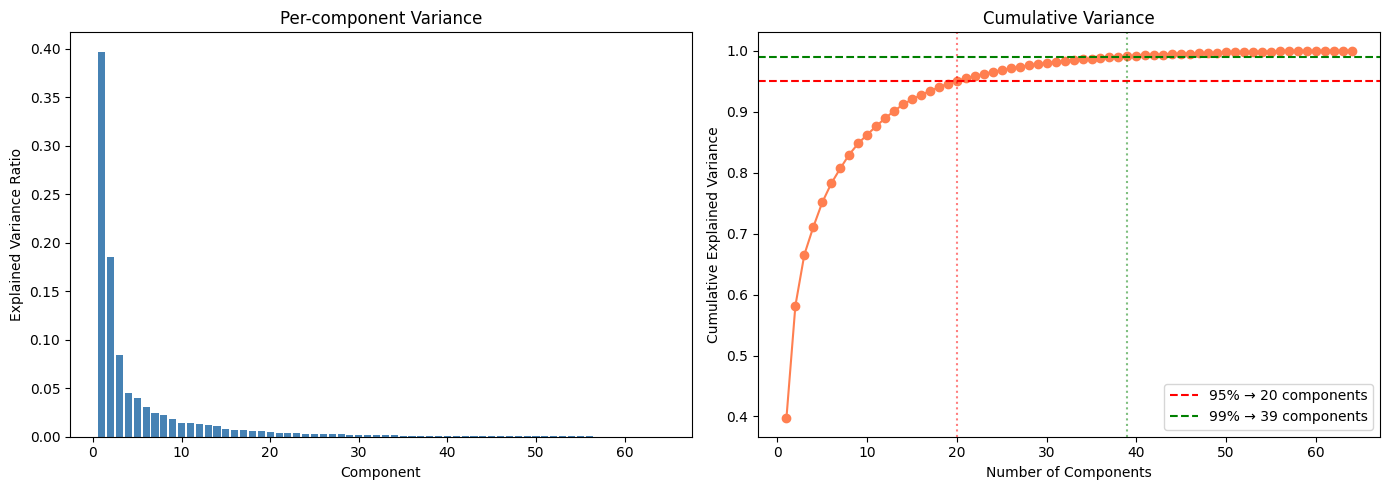


First 20 components explained variance:
  PC 1: 0.3969  (cum: 0.3969)
  PC 2: 0.1848  (cum: 0.5818)
  PC 3: 0.0839  (cum: 0.6656)
  PC 4: 0.0454  (cum: 0.7110)
  PC 5: 0.0404  (cum: 0.7513)
  PC 6: 0.0310  (cum: 0.7823)
  PC 7: 0.0246  (cum: 0.8069)
  PC 8: 0.0228  (cum: 0.8297)
  PC 9: 0.0181  (cum: 0.8478)
  PC10: 0.0145  (cum: 0.8624)
  PC11: 0.0137  (cum: 0.8761)
  PC12: 0.0133  (cum: 0.8894)
  PC13: 0.0116  (cum: 0.9010)
  PC14: 0.0109  (cum: 0.9119)
  PC15: 0.0082  (cum: 0.9201)
  PC16: 0.0073  (cum: 0.9274)
  PC17: 0.0067  (cum: 0.9341)
  PC18: 0.0061  (cum: 0.9402)
  PC19: 0.0058  (cum: 0.9460)
  PC20: 0.0049  (cum: 0.9509)


In [3]:
# Fit full PCA to see variance distribution
pca_full = PCA(n_components=64)
pca_full.fit(sampled_pixels)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% and 99% variance
n_95 = np.searchsorted(cumvar, 0.95) + 1
n_99 = np.searchsorted(cumvar, 0.99) + 1
print(f'Components for 95% variance: {n_95}')
print(f'Components for 99% variance: {n_99}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 65), pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Per-component Variance')

axes[1].plot(range(1, 65), cumvar, 'o-', color='coral')
axes[1].axhline(0.95, color='red', linestyle='--', label=f'95% → {n_95} components')
axes[1].axhline(0.99, color='green', linestyle='--', label=f'99% → {n_99} components')
axes[1].axvline(n_95, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(n_99, color='green', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nFirst 20 components explained variance:')
for i in range(20):
    print(f'  PC{i+1:2d}: {pca_full.explained_variance_ratio_[i]:.4f}  (cum: {cumvar[i]:.4f})')

In [4]:
# Fit the final PCA with chosen number of components (use 95% threshold)
N_COMPONENTS = n_95
print(f'Using {N_COMPONENTS} components (95% variance)')

pca = PCA(n_components=N_COMPONENTS)
pca.fit(sampled_pixels)
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.4f}')

Using 20 components (95% variance)
Total explained variance: 0.9509


## Step 3: Compress all files and save

Transform all train + test AEF files using the fitted PCA. Save as GeoTIFFs preserving CRS, transform, and spatial metadata.

In [5]:
def compress_aef_file(src_path, dst_path, pca_model):
    """Transform a 64-band AEF file to N_COMPONENTS-band PCA file."""
    with rasterio.open(src_path) as src:
        data = src.read()  # (64, H, W)
        profile = src.profile.copy()
        bands, h, w = data.shape
    
    # Reshape to (pixels, bands)
    pixels = data.reshape(bands, -1).T  # (H*W, 64)
    
    # Track NaN locations
    valid_mask = np.isfinite(pixels).all(axis=1)
    
    # Transform valid pixels
    compressed = np.full((h * w, pca_model.n_components), np.nan, dtype=np.float32)
    if valid_mask.any():
        compressed[valid_mask] = pca_model.transform(pixels[valid_mask]).astype(np.float32)
    
    # Reshape to (N_COMPONENTS, H, W)
    compressed_img = compressed.T.reshape(pca_model.n_components, h, w)
    
    # Update profile
    profile.update(count=pca_model.n_components, dtype='float32', nodata=np.nan)
    
    os.makedirs(dst_path.parent, exist_ok=True)
    with rasterio.open(dst_path, 'w', **profile) as dst:
        dst.write(compressed_img)
    
    return h, w, valid_mask.sum()

# Compress all files
for split, files in [('train', train_files), ('test', test_files)]:
    print(f'\n=== {split} ===')
    for f in files:
        dst = OUTPUT_DIR / split / f.name
        h, w, n_valid = compress_aef_file(f, dst, pca)
        orig_mb = f.stat().st_size / (1024**2)
        comp_mb = dst.stat().st_size / (1024**2)
        print(f'  {f.name}: {orig_mb:.1f}MB → {comp_mb:.1f}MB '
              f'({comp_mb/orig_mb*100:.0f}%) | {n_valid}/{h*w} valid px')


=== train ===
  18NWG_6_6_2020.tiff: 244.6MB → 76.5MB (31%) | 999991/1001992 valid px
  18NWG_6_6_2021.tiff: 244.6MB → 76.5MB (31%) | 999991/1001992 valid px
  18NWG_6_6_2022.tiff: 244.6MB → 76.5MB (31%) | 999991/1001992 valid px
  18NWG_6_6_2023.tiff: 244.6MB → 76.5MB (31%) | 999991/1001992 valid px
  18NWG_6_6_2024.tiff: 244.6MB → 76.5MB (31%) | 999991/1001992 valid px
  18NWG_6_6_2025.tiff: 244.6MB → 76.5MB (31%) | 999991/1001992 valid px
  18NWH_1_4_2020.tiff: 244.9MB → 76.5MB (31%) | 999991/1002996 valid px
  18NWH_1_4_2021.tiff: 244.9MB → 76.5MB (31%) | 999991/1002996 valid px
  18NWH_1_4_2022.tiff: 244.9MB → 76.5MB (31%) | 999991/1002996 valid px
  18NWH_1_4_2023.tiff: 244.9MB → 76.5MB (31%) | 999991/1002996 valid px
  18NWH_1_4_2024.tiff: 244.9MB → 76.5MB (31%) | 999991/1002996 valid px
  18NWH_1_4_2025.tiff: 244.9MB → 76.5MB (31%) | 999991/1002996 valid px
  18NWJ_8_9_2020.tiff: 244.9MB → 76.5MB (31%) | 1000129/1002996 valid px
  18NWJ_8_9_2021.tiff: 244.9MB → 76.5MB (31%) | 

## Step 4: Validation — Reconstruction Error

Inverse-transform the compressed embeddings back to 64 dims and measure how much information was lost.

In [6]:
# Pick one train file for detailed validation
test_src = train_files[0]
print(f'Validating on: {test_src.name}')

with rasterio.open(test_src) as src:
    original = src.read()  # (64, H, W)

bands, h, w = original.shape
pixels_orig = original.reshape(bands, -1).T
valid_mask = np.isfinite(pixels_orig).all(axis=1)

# Forward + inverse transform
compressed_vals = pca.transform(pixels_orig[valid_mask])
reconstructed_vals = pca.inverse_transform(compressed_vals)

# Compute errors on valid pixels only
orig_valid = pixels_orig[valid_mask]
errors = np.abs(orig_valid - reconstructed_vals)

print(f'\n--- Reconstruction Error Stats ---')
print(f'Mean absolute error:   {errors.mean():.6f}')
print(f'Max absolute error:    {errors.max():.6f}')
print(f'Median absolute error: {np.median(errors):.6f}')
print(f'RMSE:                  {np.sqrt((errors**2).mean()):.6f}')

# Per-band error
print(f'\nPer-band mean absolute error (first 10):')
for i in range(min(10, bands)):
    print(f'  Band {i+1:2d}: MAE={errors[:, i].mean():.6f}  '
          f'(orig range: [{orig_valid[:, i].min():.4f}, {orig_valid[:, i].max():.4f}])')

# Relative error
rel_error = errors / (np.abs(orig_valid) + 1e-8)
print(f'\nMean relative error: {rel_error.mean():.4%}')
print(f'Median relative error: {np.median(rel_error):.4%}')

Validating on: 18NWG_6_6_2020.tiff

--- Reconstruction Error Stats ---
Mean absolute error:   0.011643
Max absolute error:    0.141198
Median absolute error: 0.008778
RMSE:                  0.015712

Per-band mean absolute error (first 10):
  Band  1: MAE=0.012330  (orig range: [-0.1477, 0.1861])
  Band  2: MAE=0.011624  (orig range: [-0.1359, 0.3101])
  Band  3: MAE=0.013805  (orig range: [-0.0984, 0.2442])
  Band  4: MAE=0.009607  (orig range: [-0.2761, 0.0010])
  Band  5: MAE=0.012225  (orig range: [-0.1861, 0.1034])
  Band  6: MAE=0.014668  (orig range: [-0.2365, 0.2929])
  Band  7: MAE=0.009173  (orig range: [-0.1477, 0.2365])
  Band  8: MAE=0.014917  (orig range: [-0.2215, 0.1794])
  Band  9: MAE=0.016225  (orig range: [-0.1663, 0.2215])
  Band 10: MAE=0.012704  (orig range: [-0.0384, 0.3743])

Mean relative error: 11089.8491%
Median relative error: 11.3125%


## Step 5: Validation — Spatial Pattern Preservation

Compare original PCA-RGB vs compressed PCA-RGB. If the spatial patterns (forest, cleared land, rivers) look the same, the compression preserved the important structure.

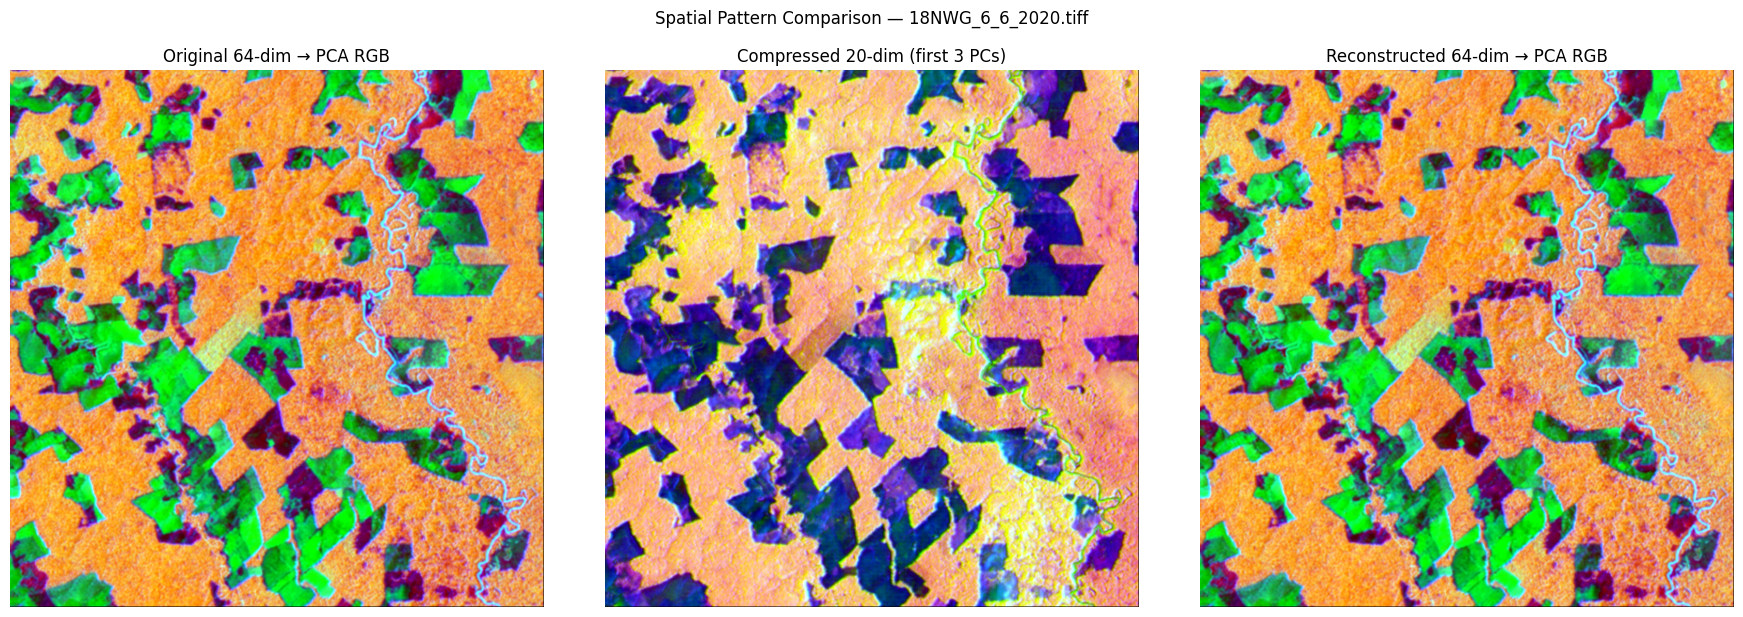

In [7]:
def make_rgb(data_3band, h, w):
    """Normalise 3 bands to 0-1 RGB image."""
    img = data_3band.reshape(h, w, 3).copy()
    for i in range(3):
        ch = img[:, :, i]
        valid = ch[np.isfinite(ch)]
        if len(valid) > 0:
            lo, hi = np.percentile(valid, [2, 98])
            img[:, :, i] = np.clip((ch - lo) / (hi - lo + 1e-8), 0, 1)
    return np.nan_to_num(img, nan=0.0)

# Original: PCA to 3 dims for visualisation
pca_vis = PCA(n_components=3)
orig_3d = np.full((h * w, 3), np.nan)
orig_3d[valid_mask] = pca_vis.fit_transform(pixels_orig[valid_mask])
orig_rgb = make_rgb(orig_3d, h, w)

# Compressed: first 3 components ARE the top 3 PCA dims
comp_path = OUTPUT_DIR / 'train' / test_src.name
with rasterio.open(comp_path) as src:
    comp_data = src.read()  # (N_COMPONENTS, H, W)
comp_3d = comp_data[:3].reshape(3, -1).T  # first 3 PCA components
comp_3d_img = np.full((h * w, 3), np.nan)
comp_3d_img[np.isfinite(comp_3d).all(axis=1)] = comp_3d[np.isfinite(comp_3d).all(axis=1)]
comp_rgb = make_rgb(comp_3d_img, h, w)

# Reconstructed from compressed
recon_full = np.full((h * w, bands), np.nan)
recon_full[valid_mask] = reconstructed_vals
recon_3d = np.full((h * w, 3), np.nan)
recon_3d[valid_mask] = pca_vis.transform(recon_full[valid_mask])
recon_rgb = make_rgb(recon_3d, h, w)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(orig_rgb)
axes[0].set_title('Original 64-dim → PCA RGB')
axes[1].imshow(comp_rgb)
axes[1].set_title(f'Compressed {N_COMPONENTS}-dim (first 3 PCs)')
axes[2].imshow(recon_rgb)
axes[2].set_title('Reconstructed 64-dim → PCA RGB')
for ax in axes:
    ax.axis('off')
plt.suptitle(f'Spatial Pattern Comparison — {test_src.name}', y=1.02)
plt.tight_layout()
plt.show()

## Step 6: Validation — NaN and Value Range Checks

Ensure compression didn't introduce new NaNs or produce values outside plausible ranges.

In [8]:
# Check every compressed file
print(f'{"File":<35s} {"Bands":>5} {"NaN orig":>10} {"NaN comp":>10} {"New NaN?":>10} {"Inf?":>5}')
print('-' * 80)

all_ok = True
for split, files in [('train', train_files), ('test', test_files)]:
    for f in files:
        # Original NaN count (per-pixel: NaN in any band)
        with rasterio.open(f) as src:
            orig = src.read()
        orig_nan = np.isnan(orig).any(axis=0).sum()
        
        # Compressed
        comp_path = OUTPUT_DIR / split / f.name
        with rasterio.open(comp_path) as src:
            comp = src.read()
        comp_nan = np.isnan(comp).any(axis=0).sum()
        has_inf = np.isinf(comp).any()
        new_nans = comp_nan > orig_nan
        
        if new_nans or has_inf:
            all_ok = False
        
        print(f'{f.name:<35s} {comp.shape[0]:>5d} {orig_nan:>10d} {comp_nan:>10d} '
              f'{"⚠️ YES" if new_nans else "✅ No":>10} {"⚠️" if has_inf else "✅":>5}')

print(f'\n{"✅ All checks passed!" if all_ok else "⚠️ Some files have issues — investigate!"}')

File                                Bands   NaN orig   NaN comp   New NaN?  Inf?
--------------------------------------------------------------------------------
18NWG_6_6_2020.tiff                    20       2001       2001       ✅ No     ✅
18NWG_6_6_2021.tiff                    20       2001       2001       ✅ No     ✅
18NWG_6_6_2022.tiff                    20       2001       2001       ✅ No     ✅
18NWG_6_6_2023.tiff                    20       2001       2001       ✅ No     ✅
18NWG_6_6_2024.tiff                    20       2001       2001       ✅ No     ✅
18NWG_6_6_2025.tiff                    20       2001       2001       ✅ No     ✅
18NWH_1_4_2020.tiff                    20       3005       3005       ✅ No     ✅
18NWH_1_4_2021.tiff                    20       3005       3005       ✅ No     ✅
18NWH_1_4_2022.tiff                    20       3005       3005       ✅ No     ✅
18NWH_1_4_2023.tiff                    20       3005       3005       ✅ No     ✅
18NWH_1_4_2024.tiff         

## Step 7: Validation — Land Cover Separability

Check that forest vs cleared pixels are still separable in the compressed space. We use the GLAD-S2 labels as a proxy to identify forest/non-forest pixels and measure cluster separation.

Forest pixels:        522327
Deforested pixels:    411026

--- Fisher Discriminant Score (higher = more separable) ---
Original (64 dims):     sum=4.2572, max=0.3449
Compressed (20 dims): sum=1.1859, max=0.2528
Ratio (compressed/orig): 0.2786


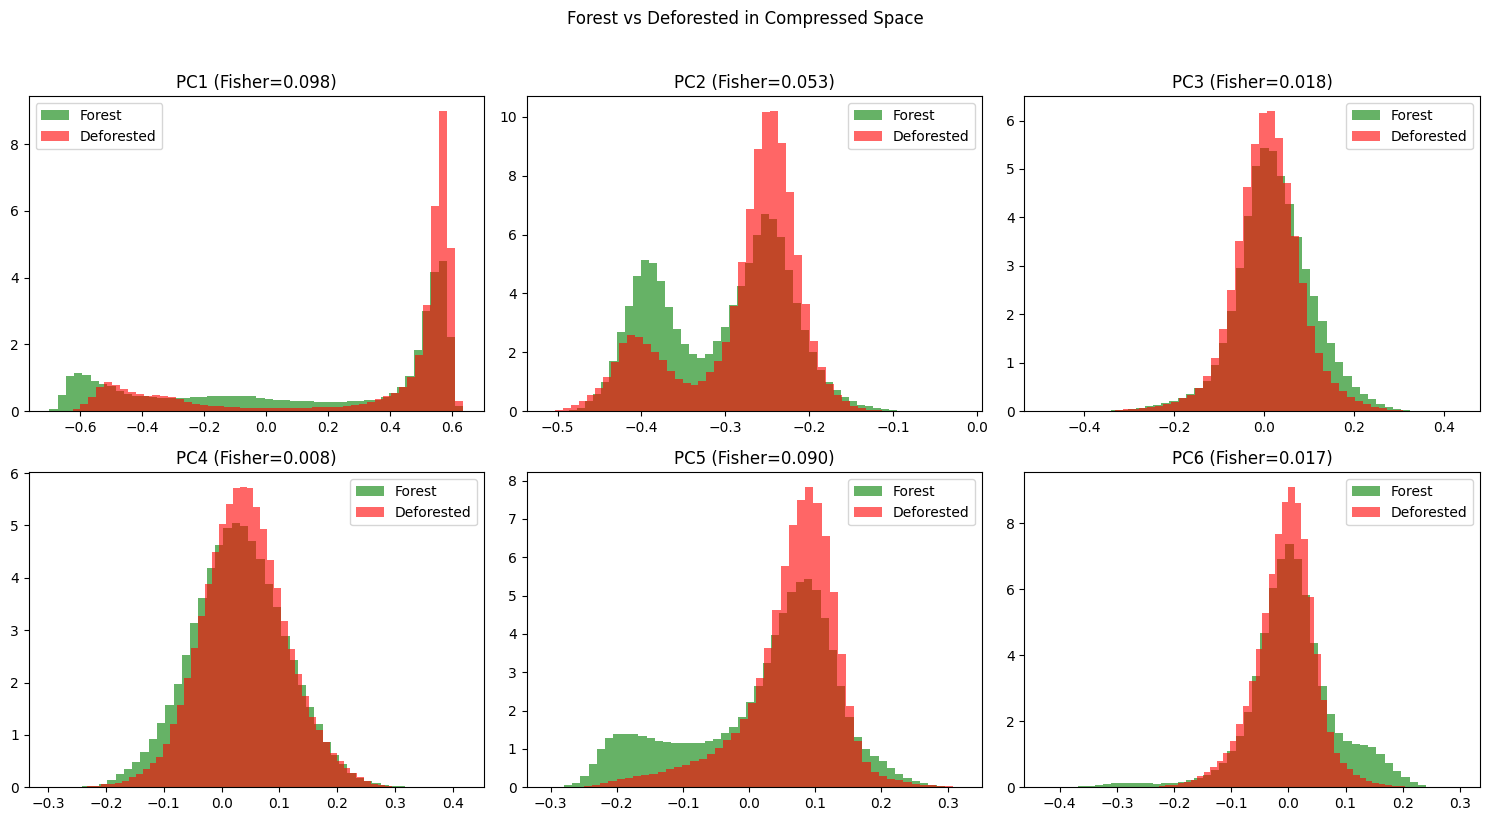

In [9]:
from rasterio.warp import reproject, Resampling

# Load a label file to get forest vs deforested pixels
label_dir = Path('../data/concept_data/labels/train/glads2')
tile_id = test_src.stem.rsplit('_', 1)[0]  # e.g. '18NWG_6_6'
alert_path = label_dir / f'glads2_{tile_id}_alert.tif'

if alert_path.exists():
    # Reproject label onto AEF grid
    with rasterio.open(test_src) as aef_src:
        aef_transform = aef_src.transform
        aef_crs = aef_src.crs
        aef_shape = (aef_src.height, aef_src.width)
    
    with rasterio.open(alert_path) as lbl_src:
        label_reproj = np.zeros(aef_shape, dtype=np.uint8)
        reproject(
            source=lbl_src.read(1),
            destination=label_reproj,
            src_transform=lbl_src.transform,
            src_crs=lbl_src.crs,
            dst_transform=aef_transform,
            dst_crs=aef_crs,
            resampling=Resampling.nearest,
        )
    
    label_flat = label_reproj.flatten()
    
    # Forest = no alert (0), Deforested = high confidence alert (3 or 4)
    forest_mask = valid_mask & (label_flat == 0)
    defor_mask = valid_mask & (label_flat >= 3)
    
    print(f'Forest pixels:      {forest_mask.sum():>8d}')
    print(f'Deforested pixels:  {defor_mask.sum():>8d}')
    
    if defor_mask.sum() > 100:
        # Compare separability in original vs compressed space
        # Use Fisher's criterion: (mu1 - mu2)^2 / (var1 + var2) per dimension
        
        orig_forest = pixels_orig[forest_mask]
        orig_defor = pixels_orig[defor_mask]
        
        comp_all = comp_data.reshape(comp_data.shape[0], -1).T  # (H*W, N_COMPONENTS)
        comp_forest = comp_all[forest_mask]
        comp_defor = comp_all[defor_mask]
        
        def fisher_score(class1, class2):
            mu_diff = (class1.mean(axis=0) - class2.mean(axis=0)) ** 2
            var_sum = class1.var(axis=0) + class2.var(axis=0) + 1e-8
            return mu_diff / var_sum
        
        fisher_orig = fisher_score(orig_forest, orig_defor)
        fisher_comp = fisher_score(comp_forest, comp_defor)
        
        print(f'\n--- Fisher Discriminant Score (higher = more separable) ---')
        print(f'Original (64 dims):     sum={fisher_orig.sum():.4f}, max={fisher_orig.max():.4f}')
        print(f'Compressed ({N_COMPONENTS} dims): sum={fisher_comp.sum():.4f}, max={fisher_comp.max():.4f}')
        print(f'Ratio (compressed/orig): {fisher_comp.sum() / fisher_orig.sum():.4f}')
        
        # Plot top PC distributions for forest vs deforested
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        for i, ax in enumerate(axes.flat):
            if i < N_COMPONENTS and i < 6:
                ax.hist(comp_forest[:, i], bins=50, alpha=0.6, color='green', label='Forest', density=True)
                ax.hist(comp_defor[:, i], bins=50, alpha=0.6, color='red', label='Deforested', density=True)
                ax.set_title(f'PC{i+1} (Fisher={fisher_comp[i]:.3f})')
                ax.legend()
        plt.suptitle('Forest vs Deforested in Compressed Space', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print('Not enough deforested pixels for separability test')
else:
    print(f'Label file not found: {alert_path}')

## Step 8: Save PCA model for reuse

Save the fitted PCA so we can apply the same transform later without re-fitting.

In [10]:
import joblib

model_path = OUTPUT_DIR / 'pca_model.joblib'
joblib.dump(pca, model_path)
print(f'PCA model saved to: {model_path}')
print(f'  Components: {pca.n_components_}')
print(f'  Explained variance: {pca.explained_variance_ratio_.sum():.4f}')

# Summary
print(f'\n=== Compression Summary ===')
print(f'Original: 64 bands')
print(f'Compressed: {N_COMPONENTS} bands')
print(f'Reduction: {(1 - N_COMPONENTS/64)*100:.0f}%')
print(f'Output dir: {OUTPUT_DIR}')

PCA model saved to: ../data/cleaned/aef-compressed/pca_model.joblib
  Components: 20
  Explained variance: 0.9509

=== Compression Summary ===
Original: 64 bands
Compressed: 20 bands
Reduction: 69%
Output dir: ../data/cleaned/aef-compressed
